In [1]:
import pytest
import numpy as np
from numba import njit
import pandas as pd
import SRCG_utils as model_utils
# import likelihood_terms_2026 as ll_terms
import pickle
import sys
sys.path.append('../')
from scipy.optimize import minimize

In [ ]:
# open fit data
with open('/Users/pradyumnasepulveda/Library/CloudStorage/GoogleDrive-pradyumna.sepulvedadelgado@nyspi.columbia.edu/My Drive/Studies/Adithya_CausalLearning/BlancoPozo_optimal_fit_Nov2025/Fitting_code_hierarchical/model_comparison_jan2026/best_parameters_2LR_iter_byPart_optimized75_FEB3.pkl', 'rb') as f:
    params_subj = pickle.load(f)

In [ ]:
param_names_n = ['base', 'rew_bonus', 'discount', 'threshold', 'temperature', 'rew_learning_rate', 'staybias']

7

In [4]:
def showParamsTable (params_subj):
    records = []
    for ii in params_subj.keys():

        best = params_subj[ii]['posterior']['mu']

        transformed = np.hstack((
        1/(1+np.exp(-best[0])),
        1/(1+np.exp(-(best[0] + best[1]))),
        1/(1+np.exp(-best[2])),
        1/(1+np.exp(-best[3])),
        np.exp(best[4]),
        1/(1+np.exp(-best[5])),
        np.tanh(best[6])
            ))

        rec = {
            'subject': ii,
            'raw_params': np.array(best, dtype=float),
            'transformed_params': np.array(transformed, dtype=float),
        }
        # split into named columns
        for name, raw_val, tr_val in zip(param_names_n, best, transformed):
            rec[f'raw_{name}'] = raw_val
            rec[name] = tr_val
        records.append(rec)

    df_params = pd.DataFrame(records).sort_values('subject').reset_index(drop=True)
    df_params['rew_bonus_trans'] = 1/(1+np.exp(-((df_params['raw_base'] + df_params['raw_rew_bonus'] ).values )))
    display(df_params)
    return df_params


In [6]:
params_df = showParamsTable (params_subj)

,subject,raw_params,transformed_params,raw_base,base,raw_rew_bonus,rew_bonus,raw_discount,discount,raw_threshold,threshold,raw_temperature,temperature,raw_rew_learning_rate,rew_learning_rate,raw_staybias,staybias,rew_bonus_trans
0,63,"[-1.199987732128537, 1.6503095107310088, 1.258...","[0.23147739889430347, 0.6107157369707974, 0.77...",-1.199988,0.231477,1.650310,0.610716,1.258229,0.778721,-0.175070,0.456344,-1.097708,0.333635,-0.083616,0.479108,0.418167,0.395385,0.610716
1,66,"[-1.680251810107516, 1.3300466033216845, 1.718...","[0.15706212795580682, 0.4133326598563211, 0.84...",-1.680252,0.157062,1.330047,0.413333,1.718540,0.847941,-0.289990,0.428006,-1.030753,0.356738,-1.134797,0.243277,0.290211,0.282329,0.413333
2,69,"[-1.9223357080941845, 1.7025849254597483, 2.92...","[0.1276013308513956, 0.4452823222315864, 0.948...",-1.922336,0.127601,1.702585,0.445282,2.923329,0.948988,-0.188297,0.453064,-1.201903,0.300622,-0.799054,0.310228,0.180541,0.178604,0.445282
3,71,"[-2.672864677584011, 3.1167938773880217, 3.219...","[0.06459366495312484, 0.6091948811181509, 0.96...",-2.672865,0.064594,3.116794,0.609195,3.219982,0.961579,-0.493506,0.379068,-0.962881,0.381791,-0.645252,0.344060,0.229360,0.225421,0.609195
4,75,"[-0.8818088866193394, 0.5616636024067336, 0.51...","[0.29280307344283085, 0.4206403413834289, 0.62...",-0.881809,0.292803,0.561664,0.420640,0.519800,0.627101,0.079965,0.519981,-0.836020,0.433432,0.081332,0.520322,0.309007,0.299533,0.420640


[0.2314774  0.61071574]


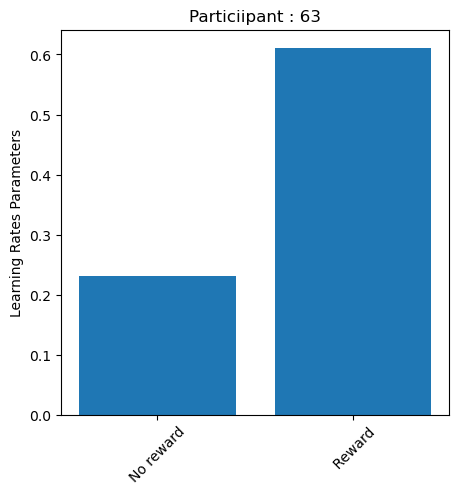

[0.15706213 0.41333266]


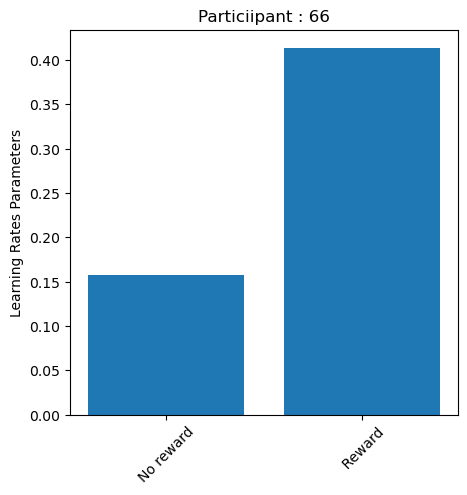

[0.12760133 0.44528232]


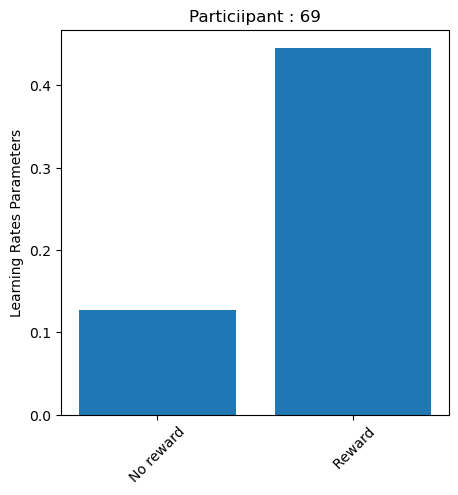

[0.06459366 0.60919488]


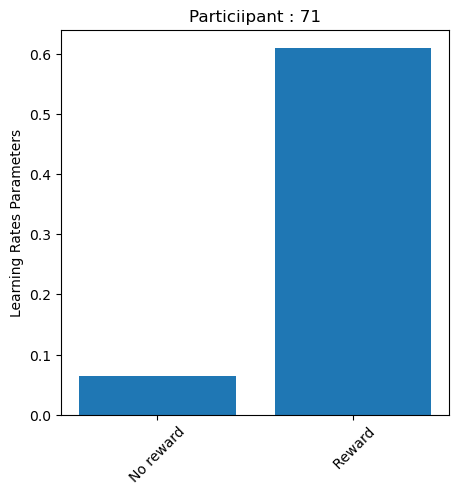

[0.29280307 0.42064034]


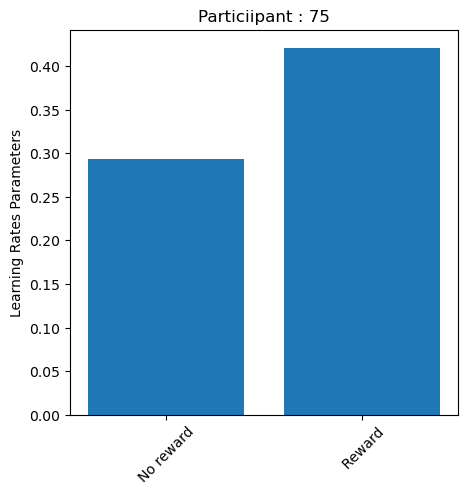

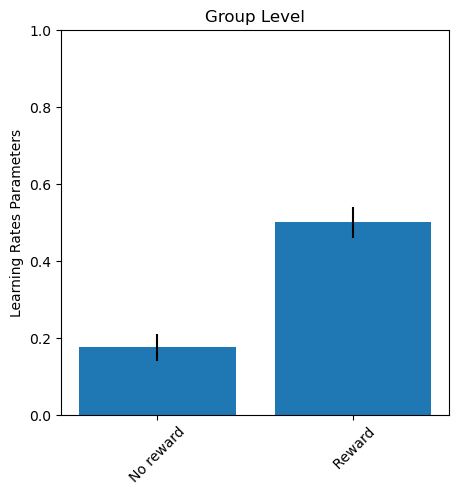

T-statistic: -4.721972628182972, P-value: 0.009158221489079481


In [7]:
import matplotlib.pyplot as plt
# list to save barplots
lr_bars = []


params1 = params_df.raw_params.tolist()
params_id = params_df.subject.tolist()
# params_df.raw_params.tolist()
for i in  range(len(params_df)):

    #     # use the animal level fitted parameters
    outputdict = params1[i]


    x_in = np.array([outputdict[0].copy(), outputdict[0].copy() + outputdict[1].copy()]) # baseline and reward params
    x_in = 1/(1 + np.exp(-x_in))
    lr_bars.append(x_in)


    plt.figure(figsize=(5,5))
    plt.bar(['No reward',' Reward'], x_in)
    print(x_in)
    plt.ylabel('Learning Rate')
    # plt.title('Learning Rates for Reward and Stimulation')
    plt.xticks(rotation=45)
    plt.ylabel('Learning Rates Parameters')
    plt.title('Particiipant : ' + str(params_id[i]))
    # plt.ylim(0,1)
    plt.show()

    # print(lr_bars)
lr_bars = np.array(lr_bars)


# plot two bars for lr_bars (use bar plots to show learning rates for reward and stimulation)
plt.figure(figsize=(5,5))
plt.bar(['No reward',' Reward'], lr_bars.mean(axis=0), yerr=lr_bars.std(axis=0)/np.sqrt(len(lr_bars)))
plt.ylabel('Learning Rate')
# plt.title('Learning Rates for Reward and Stimulation')
plt.xticks(rotation=45)
plt.ylabel('Learning Rates Parameters')
plt.title('Group Level')
plt.ylim(0,1)
plt.show()

# run t-test between learning rates for reward and stimulation
from scipy.stats import ttest_rel
t_stat, p_value = ttest_rel(lr_bars[:,0], lr_bars[:,1])
print(f"T-statistic: {t_stat}, P-value: {p_value}")


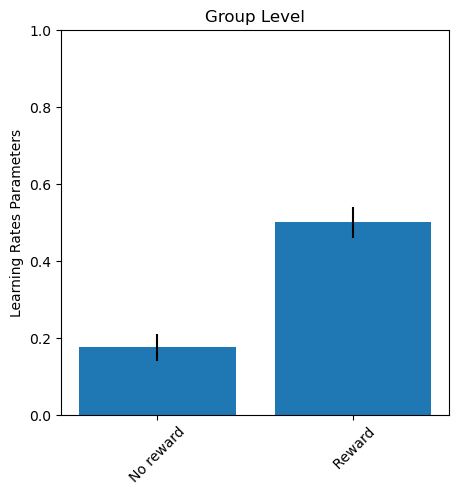

T-statistic: -4.721972628182972, P-value: 0.009158221489079481


In [ ]:
import matplotlib.pyplot as plt
# list to save barplots
lr_bars = []

params_df.raw_params.tolist()
for i in  range(len(params1)):

    #     # use the animal level fitted parameters
    outputdict = params1[i]


    x_in = np.array([outputdict[0].copy(), outputdict[0].copy() + outputdict[1].copy()]) # baseline and reward params
    lr_bars.append(1/(1 + np.exp(-x_in)))

    # print(lr_bars)
lr_bars = np.array(lr_bars)


# plot two bars for lr_bars (use bar plots to show learning rates for reward and stimulation)
# plt.figure(figsize=(5,5))
# plt.bar(['No reward',' Reward'], lr_bars.mean(axis=0), yerr=lr_bars.std(axis=0)/np.sqrt(len(lr_bars)))
# plt.ylabel('Learning Rate')
# # plt.title('Learning Rates for Reward and Stimulation')
# plt.xticks(rotation=45)
# plt.ylabel('Learning Rates Parameters')
# plt.title('Group Level')
# plt.ylim(0,1)
# plt.show()

# # run t-test between learning rates for reward and stimulation
# from scipy.stats import ttest_rel
# t_stat, p_value = ttest_rel(lr_bars[:,0], lr_bars[:,1])
# print(f"T-statistic: {t_stat}, P-value: {p_value}")


In [9]:
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib as mpl



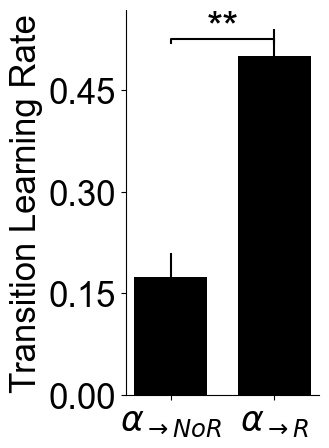

In [53]:

# generate bar plot for lr_base vs lr_rew
fig, ax = plt.subplots(figsize=(2.5,5))

mpl.rcParams['svg.fonttype'] = 'none'  # IMPORTANT
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']# size1 = 30
fontsize = 25
# use arial
plt.rcParams['font.family'] = 'Arial'

lr_base_data = lr_bars[:,0]
lr_rew_data = lr_bars[:,1]

# include error bars representing standard error of the mean
plt.bar(1, np.mean(lr_base_data), width=0.7, yerr=np.std(lr_base_data)/np.sqrt(len(lr_base_data)), label='Learning Rate Base', color='black')
plt.bar(2, np.mean(lr_rew_data), width=0.7, yerr=np.std(lr_rew_data)/np.sqrt(len(lr_rew_data)), label='Learning Rate Reward', color='black')


# add noise to the scatter points in x axis for better visualization
# plt.scatter(np.ones(len(lr_base_data)) + np.random.normal(0, 0.04, len(lr_base_data)), lr_base_data , color='black', alpha=0.3)
# plt.scatter(2*np.ones(len(lr_rew_data)) + np.random.normal(0, 0.04, len(lr_rew_data)), lr_rew_data, color='black', alpha=0.3)

plt.xticks([1, 2],     [r'$\alpha_{\rightarrow NoR}$', r'$\alpha_{\rightarrow R}$'], fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.ylabel('Transition Learning Rate', fontsize=fontsize)

# reduce the number of y-axis ticks
ax.yaxis.set_major_locator(ticker.MaxNLocator(4))


# add stars for significance
from scipy.stats import ttest_rel
t_stat, p_value = ttest_rel(lr_base_data, lr_rew_data)
if p_value < 0.001:
    plt.text(1.5, max(np.mean(lr_base_data), np.mean(lr_rew_data)) + 0.025, '***', fontsize=30, ha='center')
elif p_value < 0.01:
    plt.text(1.5, max(np.mean(lr_base_data), np.mean(lr_rew_data)) + 0.025, '**', fontsize=30, ha='center')
elif p_value < 0.05:
    plt.text(1.5, max(np.mean(lr_base_data), np.mean(lr_rew_data)) + 0.025, '*', fontsize=30, ha='center')
# add lines between bars
plt.plot([1, 1, 2, 2], [max(np.mean(lr_base_data), np.mean(lr_rew_data)) + 0.02,
                         max(np.mean(lr_base_data), np.mean(lr_rew_data)) + 0.025,
                         max(np.mean(lr_base_data), np.mean(lr_rew_data)) + 0.025,
                         max(np.mean(lr_base_data), np.mean(lr_rew_data)) + 0.02], color='black')
# plt.ylim(0, 0.5)

sns.despine()
# save figure svg
plt.savefig('Figures/SGM2026_Figure5_stay&forget_learningRates_barplot.svg', format='svg')